In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


In [4]:
# Pdiags = np.ones((Ndes,2), dtype=complex)
# Pdiags[:,1] = -1j
# Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

# Bmat = Obj
# bVec = obj
# beta = obj0

# Umat = 1j*Ztot
# eVec = 1j*Vinc/2


# QCQP = DenseSharedProjQCQP(
#     Bmat, bVec, beta,
#     Umat.conj().T, eVec,
#     Plist,
#     verbose=1,
# )

# t1 = time.time()
# lags_init = np.zeros((Pdiags.shape[1],))
# lags_init[1] = -1

# # New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
# opt_params = OptimizationHyperparameters(opttol=1e-4,                  
#     gradConverge=True,           
#     min_inner_iter=10,             
#     max_restart=10,                
#     penalty_ratio=1e-2,           
#     penalty_reduction=0.1,        
#     break_iter_period=5,          
#     verbose=1)

# # Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
# result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
# print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

In [5]:
# all material moved to the background (main.tex sec:movingMaterial)
Za = Zmat.copy()
Zd = Zmat - 2*Za # design impedance: gain (negative) where the material is moved to the background

zaDiag = np.diag(Za).astype(complex)
Ya = np.diag(np.divide(1, zaDiag, out=np.zeros_like(zaDiag), where=zaDiag != 0)) # background admittance
W0 = np.linalg.inv(Z0)
I0 = W0 @ Vinc # source current
Zb = np.linalg.inv(W0 + Ya) # background impedance: parallel combination of Z0 and Za (admittances add), not Z0 + Za
Vb = Zb @ I0 # total voltage of the background structure
Ib = Ya @ Vb # current of the background structure
T = np.eye(Ndes) - Ya @ Zb # physical current I = Ib + T dI, dI is the design current

def dItoI(dI):
    return(Ib + T @ dI)

print(f"||Vb - Zs Ifull||/||Vb||: {np.linalg.norm(Vb - Zs*Ifull)/np.linalg.norm(Vb):.2e}")

Bmat = -0.5 * Msym(T.conj().T @ R0 @ T)
bVec = 0.5 * T.conj().T @ R0 @ Ib
beta = 0.5 * np.real(Ib.conj() @ R0 @ Ib)

def evalObjdI(dI):
    return(-np.real(dI.conj().T @ Bmat @ dI) + 2*np.real(dI.conj().T @ bVec) + beta)

# real power conservation Re[I^H (Ztot I - V)] = 0 with I = Ib + T dI
B_j = [-T.conj().T @ Ztot @ T]
s_2j = [0.5 * T.conj().T @ ((Ztot + Ztot.conj().T) @ Ib - Vinc)]
c_2j = [np.real(Ib.conj() @ (Ztot @ Ib - Vinc))]

# design system (Zd + Zb) dI = Zb I0, projector constraints Re[dI^H P^H ((Zd + Zb) dI - Zb I0)] = 0
Pdiags = np.ones((Ndes,1), dtype=complex)
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

# phase 1j/(-Zs) as in the original notebook: with 1j only, P = 1 duplicates the real power constraint for arg(Zs) = 45 deg
Umat = 1j*(Zd + Zb)/(-Zs)
eVec = 1j*Vb/2/(-Zs)

def generalRes(dI):
    return(np.real(-dI.conj() @ B_j[0] @ dI + 2*dI.conj() @ s_2j[0] + c_2j[0]))

def projRes(dI, P):
    # Re[dI^H P^H (Umat dI - 2 eVec)], zero for any structure
    return(np.real(dI.conj() @ (P.conj().T @ (Umat @ dI - 2*eVec))))

# check on the empty structure (all material removed: I = 0, dI = -V/Zs) and on a random binary structure
rng = np.random.default_rng(0)
rhoTest = (rng.random(Ndes) > 0.5).astype(complex)
Itest = np.linalg.solve(Zs*np.eye(Ndes) + np.diag(rhoTest) @ Z0, rhoTest*Vinc)
for name, I in [("empty", np.zeros(Ndes, dtype=complex)), ("random", Itest)]:
    dI = I - Ya @ (Vinc - Z0 @ I)
    print(f"{name} structure: current recovery {np.linalg.norm(dItoI(dI) - I):.2e}, objective {evalObjdI(dI):.6e} W (I basis {evalObj(I):.6e} W), "
          f"constraint residuals {projRes(dI, Plist[0]):.2e}, {generalRes(dI):.2e}")
print(f"empty structure residual of (Zd + Zb) dI = Zb I0, parallel Zb: "
      f"{np.linalg.norm((Zd + Zb) @ (-Vinc/Zs) - Vb)/np.linalg.norm(Vb):.2e}, series Z0 + Za: "
      f"{np.linalg.norm((Zd + Z0 + Za) @ (-Vinc/Zs) - (Z0 + Za) @ I0)/np.linalg.norm((Z0 + Za) @ I0):.2e}")

QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat.conj().T, eVec,
    Plist,
    A2=np.eye(Ndes, dtype=complex),
    B_j=B_j,
    s_2j=s_2j,
    c_2j=c_2j,
    verbose=1,
)

t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1]+1,))
lags_init[1] = -1
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-4,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

||Vb - Zs Ifull||/||Vb||: 1.72e-12
empty structure: current recovery 1.90e-13, objective -1.776357e-15 W (I basis 0.000000e+00 W), constraint residuals 2.09e-13, 1.21e-13
random structure: current recovery 2.97e-13, objective 3.655418e-07 W (I basis 3.655418e-07 W), constraint residuals -1.02e-11, 1.92e-13
empty structure residual of (Zd + Zb) dI = Zb I0, parallel Zb: 4.64e-14, series Z0 + Za: 3.24e+04
Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
Optimizer initialized with parameters:
opttol: 0.0001
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [ 0. -1.]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 12.229409615240005
iter_num: 5, prev_fx: inf, opt_fx: 10.133604864234265, opttol: 0.0001
iter_num: 10, prev_fx: 10.133604864234265, opt_fx: 10.126677147125319, opttol: 0.0001
iter_num: 15, prev_fx: 10.126677147125319, opt_fx: 10.120933242817157,

In [6]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")


Pdiags = QCQP.Proj.Pdiags


dIvec = QCQP.current_xstar # design current
Ivec = dItoI(dIvec) # physical current
Popt = evalObj(Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.6e} W (dI basis {evalObjdI(dIvec):.6e} W)")

minimum eigenvalue: 5.884161246396869e-10
Optimal objective value: 1.012093e+01 W (dI basis 1.012093e+01 W)


In [7]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-6,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=10,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=20,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=5,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=True,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

Precomputed 2 A matrices and Fs vectors.


At GCD iteration #1, best dual bound found is             10.120932760127493.


min eigenvalue: 5.884160e-10


At GCD iteration #2, best dual bound found is             10.113198452247037.


min eigenvalue: 4.613652e-10


...

At GCD iteration #17, best dual bound found is             10.110419996911538.
min eigenvalue: 4.401143e-10


At GCD iteration #18, best dual bound found is             10.110359017074934.
min eigenvalue: 4.400039e-10


At GCD iteration #19, best dual bound found is             10.110302497482992.
min eigenvalue: 4.403775e-10


At GCD iteration #20, best dual bound found is             10.110254352217801.
min eigenvalue: 4.405891e-10


At GCD iteration #21, best dual bound found is             10.110205413674196.
gcd optimization took time 3.411801815032959.


In [8]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 4.4068616011714766e-10


In [9]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
Pdiags = gcd_QCQP.Proj.Pdiags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

dIvec = gcd_QCQP.current_xstar # design current
Ivec = dItoI(dIvec) # physical current

primar_obj = evalObj(Ivec)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

bound: 10.110205413674198, time: 0.12250542640686035s
min eigenvalue: 4.4068616081572035e-10
GCD primary objective: 10.11020542273628
GCD dual bound: 10.110205413674198


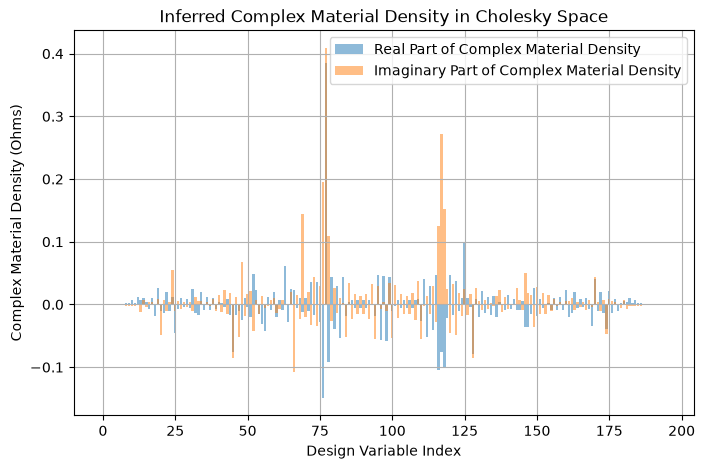

In [10]:
Vopt = Vinc - Z0 @ Ivec # total voltage

sigmaInf = dIvec/Vopt # design admittance
sigmaFull = 1/Zs

complexMaterialDensity = np.diag(Za)/Zs + sigmaInf/sigmaFull # background density + design density (= Zs I / Vopt)

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


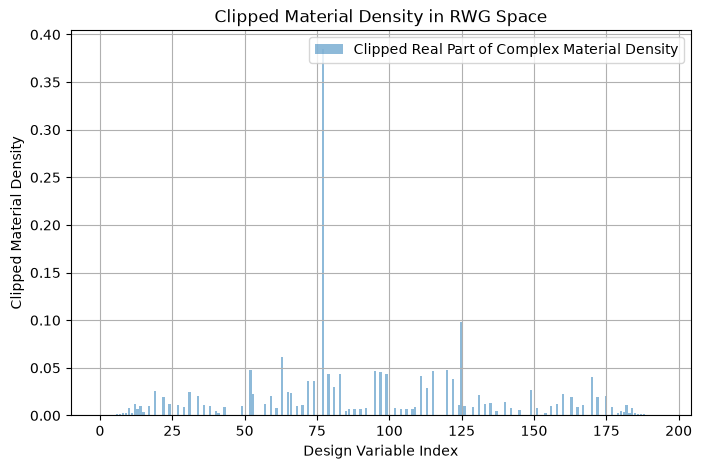

Objective for clipped inferred material density: 1.9590e-06 W


In [11]:
# limit material density to be postive real [0,1]
material_density = np.clip(np.real(complexMaterialDensity), 0, 1)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Clipped Real Part of Complex Material Density')
plt.xlabel('Design Variable Index') 
plt.ylabel('Clipped Material Density')
plt.title('Clipped Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

sigmaClipped = 1/Zs*material_density
IfullInfClip = np.linalg.solve(np.eye(Ndes) + np.diag(sigmaClipped) @ Z0, np.diag(sigmaClipped) @ Vinc) # current distribution for inferred material density
PfullInfClip= evalObj(IfullInfClip) # radiated power for inferred material density
print(f"Objective for clipped inferred material density: {PfullInfClip:.4e} W")